## Import trial data for quantifying behavioral metrics
(From locally saved dataframes)

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings('ignore')
import os
import seaborn as sns
import re
import numpy as np
import datajoint as dj
import pandas as pd
import matplotlib.pyplot as plt
import sys
import importlib
import scipy
import math
from scipy import signal, stats
import matplotlib as mpl
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.stats import wilcoxon, mannwhitneyu, norm
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
import statsmodels.api as sm
from statsmodels.genmod.bayes_mixed_glm import BinomialBayesMixedGLM
import statsmodels.formula.api as smf
from __future__ import annotations
from dataclasses import dataclass
from typing import Dict, List, Optional, Sequence, Tuple
import itertools
import copy
from collections import Counter
from matplotlib import cm

fig_dir = '/stelmo/xulu/plots/'
results_dir = '/home/xulu/code/MetaLearningDynamics/results_for_plotting/'
data_dir = '/home/xulu/code/MetaLearningDynamics/example_data/'

In [3]:
def get_behav_data(file,use_selected_sessions=False,exclude_trials_by_duration=False):
    
    # Load behavioral dataframe saved locally.    
    trialData = pd.read_pickle(data_dir+f'{file}_behav_dataframe.pkl')
    # If we need to drop sessions with low performance (as measured by reward rate)
    epoch_selected = trialData.epoch.unique()
    if use_selected_sessions:
        if np.isin(file,['senor20201116','j1620210719']):
            epoch_selected = epoch_selected[[0,2,3,4]]
        if np.isin(file,['peanut20201205','wilbur20210408','wilbur20210409']):
            epoch_selected = epoch_selected[:-1]
        if np.isin(file,['peanut20201206']):
            epoch_selected = epoch_selected[1:]
        if np.isin(file, ['peanut20201208']):
            epoch_selected = epoch_selected[[0,1,2,4]]
        if np.isin(file, ['senor20201121']):
            epoch_selected = epoch_selected[[0,2,4]]
        if np.isin(file,['peanut20201209','senor20201113','senor20201114']):
            epoch_selected = epoch_selected[[0,1,3,4]]
    print(f'{file}: epochs {epoch_selected} included')
    trialData = trialData[trialData.epoch.isin(epoch_selected)]

    # Drop trials that are either too short (could be due to pos tracking error) or too long (indicating long pauses in the middle of a run)
    if exclude_trials_by_duration:
        trialData = trialData[np.logical_and(trialData.Duration >= 2.5,trialData.Duration <= 12)]
 
    return trialData


In [4]:
def get_movement_data(file,use_selected_sessions=False,exclude_trials_by_duration=False,alignment=None,aligned_interval=None):
    
    # Load behavioral dataframe saved locally.    
    trialData = pd.read_pickle(data_dir+f'{file}_behav_dataframe.pkl')
    
    # If we need to drop sessions with low performance (as measured by reward rate)
    epoch_selected = trialData.epoch.unique()
    if use_selected_sessions:
        if np.isin(file,['senor20201116','j1620210719']):
            epoch_selected = epoch_selected[[0,2,3,4]]
        if np.isin(file,['peanut20201205','wilbur20210408','wilbur20210409']):
            epoch_selected = epoch_selected[:-1]
        if np.isin(file,['peanut20201206']):
            epoch_selected = epoch_selected[1:]
        if np.isin(file, ['peanut20201208']):
            epoch_selected = epoch_selected[[0,1,2,4]]
        if np.isin(file, ['senor20201121']):
            epoch_selected = epoch_selected[[0,2,4]]
        if np.isin(file,['peanut20201209','senor20201113','senor20201114']):
            epoch_selected = epoch_selected[[0,1,3,4]]
    print(f'{file}: epochs {epoch_selected} selected')
    trialData = trialData[trialData.epoch.isin(epoch_selected)]
    
    # Drop trials that are either too short (could be due to pos tracking error) or too long (indicating long pauses in the middle of a run)
    if exclude_trials_by_duration:
        trialData = trialData[np.logical_and(trialData.Duration >= 2.5,trialData.Duration <= 12)]
            
    speed = []
    ##### load locally saved position dataframes below #######
    fetch_pos_dataframe(nwb_file_name)
    position = pd.read_pickle(data_dir + f'{file}_position.pkl')

    for i in trialData[trialData.epoch.isin(epoch_selected)].index:
        start = trialData.loc[i][alignment] + aligned_interval[0]
        end = trialData.loc[i][alignment] + aligned_interval[1]
        speed.append(position.head_speed[np.array(position.index>=start) & np.array(position.index<=end)])
    
    empty_indices = [i for i, s in enumerate(speed) if s.size == 0]
    print(empty_indices)
    speed = [s for s in speed if s.size > 0]        
    sizes = [s.size for s in speed]
    min_size = min(sizes)
    speed_sl = [s.iloc[:min_size] for s in speed]
    speed_ar = np.stack([s.values for s in speed_sl])
    return speed_ar


In [5]:
#### Initialize the multi-animal multi-day behav metric dictionaries.
if not 'others_to_best' in locals():
    others_to_best_trials = dict()
    others_to_best = dict()
    best_to_medium_trials = dict()
    best_to_medium = dict()
    bout_length_best_alltrials = dict()
    bout_length_best = dict()
    bout_length_medium_alltrials = dict()
    bout_length_medium = dict()
    bout_length_nonbest_postbest = dict()
    switch_postreward_trials = dict()
    switch_postreward = dict()
    speed_pause = dict()
    speed_run = dict()
    reward_rate_allsesh = dict()

## Meta-learning related behavioral metrics.

### Likelihood of choosing high-rew/medium-rew patches, bout lengths, switch after rewards (Fig. 1)

In [19]:
# NOTE: this section loads preexisting dataframes saved locally #
file_names = {'j16':['j1620210714','j1620210715','j1620210716','j1620210717','j1620210718','j1620210719'],\
              'wilbur':['wilbur20210404','wilbur20210405','wilbur20210406','wilbur20210407','wilbur20210408','wilbur20210409','wilbur20210410'],\
              'senor':['senor20201109','senor20201111','senor20201113','senor20201114','senor20201116','senor20201121'],\
              'peanut':['peanut20201203','peanut20201205','peanut20201206','peanut20201208','peanut20201209']}

file_name = 'wilbur20210408'
save_results = False
use_selected_sessions = False
exclude_trials_by_duration = True # Useful for excluding trials when the rat rested for a long period in the middle of a trial, but cannot be True if we want to do analysis on strictly successive trials.

late_trials_only = True
early_trials_only = False
trial_label = ""
for subject in file_names.keys():
    for file_name in file_names[subject]:
        if np.isin(file_name,['j1620210714','wilbur20210404','peanut20201203','senor20201109']):
            probs_choosing_medium = np.empty(shape=(0,))
            trials_choosing_medium = np.empty(shape=(0,2))
            probs_choosing_best = np.empty(shape=(0,))
            trials_choosing_best = np.empty(shape=(0,2))
            pokes_before_switch_best_alltrials = []
            pokes_before_switch_best = np.empty(shape=(0,))
            pokes_before_switch_medium_alltrials = []
            pokes_before_switch_medium = np.empty(shape=(0,))
            value_before_switch_best = np.empty(shape=(0,))
            value_before_switch_medium = np.empty(shape=(0,))
            trials_switch_postrew = np.empty(shape=(0,2))
            portion_switch_postrew = np.empty(shape=(0,))
            pokes_before_switch_nonbest_postbest = np.empty(shape=(0,))

        behavData = get_behav_data(file=file_name,use_selected_sessions=use_selected_sessions,exclude_trials_by_duration=exclude_trials_by_duration)
        
        switch_from_best = behavData[(behavData.StartStem == behavData.BestStem) & (behavData.IsSwitch)]
        switch_from_nonbest = behavData[(behavData.StartStem != behavData.BestStem) & (behavData.IsSwitch)]
        
        ##### Use a threshold if we only analyze early trials or late trials of each session (given that rats might be using different strategies early-on vs. later).
        threshold = 150
        if late_trials_only:
            switch_from_best = switch_from_best[switch_from_best.trial_number_by_epoch>=threshold]
            switch_from_nonbest = switch_from_nonbest[switch_from_nonbest.trial_number_by_epoch>=threshold]
            # Nonbest-patch switch trials where the previous patch was the high-rew (best) patch
            switch_from_nonbest_after_best = switch_from_nonbest[np.array(behavData.loc[(switch_from_nonbest.index - np.array(switch_from_nonbest.pokes_before_switch)).astype(int)].StartStem == \
                                                                          behavData.loc[(switch_from_nonbest.index - np.array(switch_from_nonbest.pokes_before_switch)).astype(int)].BestStem)]
            trial_data_thesholded = behavData[behavData.trial_number_by_epoch>=threshold]
            pokes_before_switch_best_singletrials = switch_from_best.pokes_before_switch
            pokes_before_switch_medium_singletrials = behavData[(behavData.trial_number_by_epoch>=threshold)\
                                                                         & (behavData.trial_id_before_switch==0)\
                                                                         & (behavData.StartStem == behavData.MediumStem)].pokes_before_switch
            pokes_before_switch_nonbest_singletrials = behavData[(behavData.trial_number_by_epoch>=threshold)\
                                                                         & (behavData.trial_id_before_switch==0)\
                                                                         & (behavData.StartStem != behavData.BestStem)].pokes_before_switch
            trial_label = f'_trials{threshold}-300'
            
        if early_trials_only:
            switch_from_best = switch_from_best[switch_from_best.trial_number_by_epoch<threshold]
            switch_from_nonbest = switch_from_nonbest[switch_from_nonbest.trial_number_by_epoch<threshold]
            switch_from_nonbest_after_best = switch_from_nonbest[np.array(behavData.loc[(switch_from_nonbest.index - np.array(switch_from_nonbest.pokes_before_switch)).astype(int)].StartStem == \
                                                                          behavData.loc[(switch_from_nonbest.index - np.array(switch_from_nonbest.pokes_before_switch)).astype(int)].BestStem)]    
            trial_data_thesholded = behavData[behavData.trial_number_by_epoch<threshold]
            pokes_before_switch_best_singletrials = switch_from_best.pokes_before_switch
            pokes_before_switch_medium_singletrials = behavData[(behavData.trial_number_by_epoch<threshold)\
                                                                         & (behavData.trial_id_before_switch==0)\
                                                                         & (behavData.StartStem == behavData.MediumStem)].pokes_before_switch
            pokes_before_switch_nonbest_singletrials = behavData[(behavData.trial_number_by_epoch<threshold)\
                                                                         & (behavData.trial_id_before_switch==0)\
                                                                         & (behavData.StartStem != behavData.BestStem)].pokes_before_switch 
            trial_label = f'_trials0-{threshold}'
        
        trials_choosing_best = np.vstack((trials_choosing_best,[(switch_from_nonbest.EndStem == switch_from_nonbest.BestStem).sum(),switch_from_nonbest.shape[0]]))
        probs_choosing_best = np.concatenate((probs_choosing_best,[(switch_from_nonbest.EndStem == switch_from_nonbest.BestStem).sum()/switch_from_nonbest.shape[0]]))
        trials_choosing_medium = np.vstack((trials_choosing_medium,[(switch_from_best.EndStem == switch_from_best.MediumStem).sum(),switch_from_best.shape[0]]))
        probs_choosing_medium = np.concatenate((probs_choosing_medium,[(switch_from_best.EndStem == switch_from_best.MediumStem).sum()/switch_from_best.shape[0]]))
        pokes_before_switch_best_alltrials.append(np.array(pokes_before_switch_best_singletrials))
        pokes_before_switch_best = np.concatenate((pokes_before_switch_best,[pokes_before_switch_best_singletrials.mean()]))
        pokes_before_switch_medium_alltrials.append(np.array(pokes_before_switch_medium_singletrials))
        pokes_before_switch_medium = np.concatenate((pokes_before_switch_medium,[pokes_before_switch_medium_singletrials.mean()]))
        pokes_before_switch_nonbest_alltrials.append(np.array(pokes_before_switch_nonbest_singletrials))
        pokes_before_switch_nonbest = np.concatenate((pokes_before_switch_nonbest,[pokes_before_switch_nonbest_singletrials.mean()]))
        pokes_before_switch_nonbest_postbest = np.concatenate((pokes_before_switch_nonbest_postbest,[switch_from_nonbest_after_best.pokes_before_switch.mean()]))
        trials_switch_postrew = np.vstack((trials_switch_postrew,[switch_from_nonbest[switch_from_nonbest.RewardPrevious==1].shape[0],switch_from_nonbest.shape[0]]))
        portion_switch_postrew = np.concatenate((portion_switch_postrew,[switch_from_nonbest[switch_from_nonbest.RewardPrevious==1].shape[0]/switch_from_nonbest.shape[0]]))    
    
    # Store multi-day behav metrics per rat
    others_to_best_trials[subject] = trials_choosing_best
    others_to_best[subject] = probs_choosing_best
    best_to_medium_trials[subject] = trials_choosing_medium
    best_to_medium[subject] = probs_choosing_medium
    bout_length_best_alltrials[subject] = pokes_before_switch_best_alltrials
    bout_length_best[subject] = pokes_before_switch_best
    bout_length_medium_alltrials[subject] = pokes_before_switch_medium_alltrials
    bout_length_medium[subject] = pokes_before_switch_medium
    bout_length_nonbest_alltrials[subject] = pokes_before_switch_nonbest_alltrials
    bout_length_nonbest[subject] = pokes_before_switch_nonbest
    bout_length_nonbest_postbest[subject] = pokes_before_switch_nonbest_postbest
    switch_postreward_trials[subject] = trials_switch_postrew
    switch_postreward[subject] = portion_switch_postrew

if save_results:
    np.savez(results_dir+f"j16+wilbur+peanut+senor_behavioral_metalearning_metrics_across_all_days{trial_label}.npz",\
         others_to_best_trials = others_to_best_trials, others_to_best = others_to_best, best_to_medium_trials = best_to_medium_trials, best_to_medium = best_to_medium, \
         bout_length_best_alltrials = bout_length_best_alltrials, bout_length_best = bout_length_best,bout_length_medium_alltrials = bout_length_medium_alltrials,\
         bout_length_medium = bout_length_medium,bout_length_nonbest_alltrials = bout_length_nonbest_alltrials, bout_length_nonbest = bout_length_nonbest,\
         switch_postreward_trials = switch_postreward_trials, switch_postreward = switch_postreward, bout_length_nonbest_postbest = bout_length_nonbest_postbest,allow_pickle=True)


805020802020
A B
502020205080
C A
502080505020
B A
202020502080
C B
502080502020
B A
508020208020
A C
 The recording is 415 min long
j1620210714: epochs [ 2  4  6  8 10 12] selected
202080502080
B C
802050202020
A B
202080208050
C B
205020802020
B A
508020205020
A C
 The recording is 392 min long
j1620210715: epochs [ 2  4  6  8 10] selected
205020202080
C A
202080208050
C B
502050802020
B A
802020202050
A C
205050808020
B C
 The recording is 391 min long
j1620210716: epochs [ 2  4  6  8 10] selected
208050202020
A B
202080205080
C B
205050802020
B A
802020202050
A C
202020508050
C B
 The recording is 382 min long
j1620210717: epochs [ 2  4  6  8 10] selected
202080208050
C B
202020805020
B C
805020202050
A C
202080205080
C B
505050802020
B A
 The recording is 391 min long
j1620210718: epochs [ 2  4  6  8 10] selected
205020208020
C A
802020505020
A B
502050802080
B C
508080202020
A B
502020208020
C A
 The recording is 339 min long
j1620210719: epochs [ 2  4  6  8 10] selected
20205080

### Reward rate across days (Extended Data Fig. 1)

In [14]:
####### TODO: Combine the bollowing code with the last section #########
########################################################################

####### Calculate reward rate per session #######
reward_rate_allrats = dict()
min_trials_learning = dict()
file_names = {'j16':['j1620210714','j1620210715','j1620210716','j1620210717','j1620210718','j1620210719'],\
              'wilbur':['wilbur20210404','wilbur20210405','wilbur20210406','wilbur20210407','wilbur20210408','wilbur20210409','wilbur20210410'],\
              'senor':['senor20201109','senor20201111','senor20201113','senor20201114','senor20201116','senor20201121'],\
              'peanut':['peanut20201203','peanut20201205','peanut20201206','peanut20201208','peanut20201209']}

use_selected_sessions = False
exclude_trials_by_duration = False # Cannot use True if we want to analyze successive trials

for subject in file_names.keys():
    for file_name in file_names[subject]:
        if np.isin(file_name,['j1620210714','wilbur20210404','peanut20201203','senor20201109']):
            reward_rate_allsesh = []
            min_trials_allsesh = []
            
        behavData = get_behav_data(file=file_name,use_selected_sessions=use_selected_sessions,exclude_trials_by_duration=exclude_trials_by_duration)
        for epoch in behavData.epoch.unique():
            if epoch == 2:
                reward_rate = []
                min_trials = []
            reward_rate.append(behavData[behavData.epoch==epoch].Reward.sum()/behavData[behavData.epoch==epoch].shape[0])            
            best_patch = behavData[behavData.epoch==epoch].BestStem.unique()[0]
            print(f'best patch is {best_patch}')

        reward_rate_allsesh.append(np.array(reward_rate))
    reward_rate_allrats[subject] = reward_rate_allsesh


[18:28:27][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: fetch_nwb (helper function)
[18:28:27][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: get_nwb_table
	Use FetchMixin.fetch_nwb() (logic integrated into mixin) instead


805020802020
A B
502020205080
C A
502080505020
B A
202020502080
C B
502080502020
B A
508020208020
A C


[18:28:53][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: fetch_nwb (helper function)
[18:28:53][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: get_nwb_table
	Use FetchMixin.fetch_nwb() (logic integrated into mixin) instead


 The recording is 415 min long
j1620210714: epochs [ 2  4  6  8 10 12] selected
best patch is A
best patch is C
best patch is B
best patch is C
best patch is B
best patch is A
202080502080
B C
802050202020
A B
202080208050
C B
205020802020
B A
508020205020
A C


[18:29:17][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: fetch_nwb (helper function)
[18:29:17][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: get_nwb_table
	Use FetchMixin.fetch_nwb() (logic integrated into mixin) instead


...

[18:39:45][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: fetch_nwb (helper function)
[18:39:45][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: get_nwb_table
	Use FetchMixin.fetch_nwb() (logic integrated into mixin) instead


 The recording is 376 min long
peanut20201206: epochs [ 2  4  6  8 10] selected
best patch is B
best patch is C
best patch is A
best patch is B
best patch is C
205080202020
B A
502020805080
C B
802050202020
A B
505050208050
C A
202020802050
B C


[18:40:11][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: fetch_nwb (helper function)
[18:40:11][WARNING] Spyglass: DEPRECATION scheduled for Spyglass 0.6.0: get_nwb_table
	Use FetchMixin.fetch_nwb() (logic integrated into mixin) instead


 The recording is 360 min long
peanut20201208: epochs [ 2  4  6  8 10] selected
best patch is B
best patch is C
best patch is A
best patch is C
best patch is B
502020208050
C A
802020502020
A B
208050205080
C A
202050808020
B C
508020202050
A C
 The recording is 360 min long
peanut20201209: epochs [ 2  4  6  8 10] selected
best patch is C
best patch is A
best patch is C
best patch is B
best patch is A


NameError: name 'trial_label' is not defined

### Load precomputed results

In [53]:
a = np.load(results_dir+f"j16+wilbur+senor+peanut_behavioral_metalearning_metrics.npz",allow_pickle=True)

others_to_best_trials = a.f.others_to_best_trials.item()
others_to_best = a.f.others_to_best.item()
best_to_medium_trials = a.f.best_to_medium_trials.item()
best_to_medium = a.f.best_to_medium.item()
bout_length_best_alltrials = a.f.bout_length_best_alltrials.item()
bout_length_best = a.f.bout_length_best.item()
bout_length_medium_alltrials = a.f.bout_length_medium_alltrials.item()
bout_length_medium = a.f.bout_length_medium.item()
# bout_length_nonbest_alltrials = a.f.bout_length_nonbest_alltrials.item()
# bout_length_nonbest = a.f.bout_length_nonbest.item()
switch_postreward_trials = a.f.switch_postreward_trials.item()
switch_postreward = a.f.switch_postreward.item()
bout_length_nonbest_postbest = a.f.bout_length_nonbest_postbest.item()
reward_rate_allrats=a.f.reward_rate.item()


In [8]:
# Indices of late learning days for each animal (early learning is always day 1; late learning is sessions in days 5-7)
late_day = dict()
late_day['j16'] = [4,5]
late_day['wilbur'] = [4,5,6]
late_day['senor'] = [2,3,4]
late_day['peanut'] = [3,4]

### Statistical tests of late-learning vs. early-learning behavioral metrics per rat:

In [23]:
# z test for individual trials under the assumption of following binomial distribution
behav_metric = others_to_best_trials
# behav_metric = best_to_medium_trials
# behav_metric = switch_postreward_trials
for animal in ['j16','wilbur','senor','peanut']:
    k1, n1 = behav_metric[animal][0][0], behav_metric[animal][0][1]
    k2, n2 = behav_metric[animal][late_day[animal]][:,0].sum(), behav_metric[animal][late_day[animal]][:,1].sum()
    
    # One-sided:
    stat, p_one_sided = proportions_ztest([k1, k2], [n1, n2], alternative="smaller")
    # stat, p_one_sided = proportions_ztest([k1, k2], [n1, n2], alternative="larger")
    print(f'{animal}: {stat},{p_one_sided}')

# 95% CI for each condition or for their difference:
low_early, high_early = proportion_confint(count=k1, nobs=n1, alpha=0.05, method="wilson")
low_late, high_late = proportion_confint(count=k1, nobs=n1, alpha=0.05, method="wilson")

# low, high = confint_proportions_2indep(count1=k1, nobs1=n1,
#                                        count2=k2, nobs2=n2,
#                                        method="score")  # good default
# print((low, high))

j16: -5.074490768017843,1.9426754690953993e-07
wilbur: -3.8857687382762593,5.100328961355915e-05
senor: -5.376109667401786,3.8056221493807285e-08
peanut: -3.8762419408801727,5.304110288413036e-05


In [63]:
# Wilcoxon tests for individual trials

# behav_metric = bout_length_best_alltrials
# behav_metric = bout_length_medium_alltrials
behav_metric = reward_rate_allrats
for animal in ['j16','wilbur','senor','peanut']:
    # stat,p_one_sided = mannwhitneyu(behav_metric[animal][0],np.concatenate([behav_metric[animal][i] for i in late_day[animal]]),alternative='greater')
    stat,p_one_sided = mannwhitneyu(behav_metric[animal][0],np.concatenate([behav_metric[animal][i] for i in late_day[animal]]),alternative='less')
    print(f'{animal}: {stat},{p_one_sided}')

j16: 8.0,0.00976023856194008
wilbur: 11.0,0.011542350876922328
senor: 13.0,0.016382868937048503
peanut: 2.0,0.001332001332001332


### Plot single-trial meta-learning behav metrics, multi-day & multi-animal (as in Fig. 1 and Extended Data Fig. 1).

In [17]:
def plot_two_condition(data, cond_labels=("Early", "Late"),ylabel="Proportion",
                    jitter=0.1, point_size=7, seed=2,save_name=""):
    animals = data.keys()
    # colors per animal
    colormap1 = cm.tab20b(np.linspace(0,1,20))
    colormap2 = cm.tab20(np.linspace(0,1,20))
    colors= np.concatenate((colormap1[[14,2,18],:],colormap2[[-2],:]))

    rng = np.random.default_rng(2)  # reproducible jitter
    jit = rng.normal(0, jitter, size=len(animals))

    fig, ax = plt.subplots(figsize=(3, 4))
    xticks, xticklabels = [], []

    x_early, x_late = 0.0, 1.0
    marker = "o"

    for i, animal in enumerate(animals):
        early_arr = data[animal]['early']
        late_arr = data[animal]['late']

        m_e = early_arr.mean() 
        m_l = late_arr.mean()
        print(early_arr.std())
        print(late_arr.std())
        
        mfc, mec, mew = colors[i], 'none', 0.5

        # Early
        # If we want to use SEM: early_arr.std()/math.sqrt(early_arr.shape[0])
        ax.errorbar(x_early + jit[i], m_e, yerr=early_arr.std(),
                    fmt=marker, ms=point_size,
                    mfc=mfc, mec=mec, mew=mew,
                    color=colors[i], ecolor=colors[i],
                    capsize=5, capthick=0.5, elinewidth=0.5)

        # Late
        ax.errorbar(x_late + jit[i], m_l, yerr=late_arr.std(),
                    fmt=marker, ms=point_size,
                    mfc=mfc, mec=mec, mew=mew,
                    color=colors[i], ecolor=colors[i],
                    capsize=5, capthick=0.5, elinewidth=0.5)
        
        ax.plot([x_early + jit[i],x_late + jit[i]], [m_e,m_l], color='gray', linewidth = 0.5, alpha=.5) # Add gray line between pairs of dat
        
    # x-ticks/labels
    xticks.extend([x_early, x_late])

    ax.set_xlim(-0.5, 1.5)
    # ax.set_ylim(np.nanmin([0, ax.get_ylim()[0]]), np.nanmax([1, ax.get_ylim()[1]]))
    # ax.set_ylim(2, np.nanmax([1, ax.get_ylim()[1]]))
    ax.set_xticks([x_early, x_late])
    ax.set_xticklabels(cond_labels)
    ax.set_ylabel(ylabel)
    
    # Legend: one color per animal, filled swatch
    handles = [Line2D([0],[0], marker='o', linestyle='None', color='none',
                      markerfacecolor=colors[i], markeredgecolor='none', markeredgewidth=0,
                      markersize=point_size, label=f"Rat {animal[0].upper()}") for i,animal in enumerate(animals)]
    ax.legend(handles=handles, frameon=False, ncol=1)

    plt.tight_layout()
    sns.despine(trim=True,left=False)

    if len(save_name) != 0:
         plt.savefig(save_name, transparent = True)

In [40]:
def plot_two_condition_binom(k1, n1, k2, n2, animals, cond_labels=("Cond 1", "Cond 2"), jitter=0.07, ylabel="Proportion",save_name=""):
    """
    k1, n1, k2, n2: 1D arrays (same length as #animals), indicating successes and total #trials.
    Plots two columns (conditions), jittered points per animal, with 95% Wilson CIs.
    """
    k1, n1, k2, n2 = map(np.asarray, (k1, n1, k2, n2))
    assert k1.shape == n1.shape == k2.shape == n2.shape

    props1 = k1 / n1
    props2 = k2 / n2
    ci1 = np.array([proportion_confint(count=k, nobs=n, alpha=0.05, method="wilson") for k, n in zip(k1, n1)])
    ci2 = np.array([proportion_confint(count=k, nobs=n, alpha=0.05, method="wilson") for k, n in zip(k2, n2)])

    # x positions
    x1, x2 = 0.0, 1.0
    rng = np.random.default_rng(2)  # reproducible jitter
    jit = rng.normal(0, jitter, size=len(k1))

    # colors per animal
    colormap1 = cm.tab20b(np.linspace(0,1,20))
    colormap2 = cm.tab20(np.linspace(0,1,20))
    colors= np.concatenate((colormap1[[14,2,18],:],colormap2[[-2],:]))

    fig, ax = plt.subplots(figsize=(3, 4))

    for i in range(len(k1)):
        y = props1[i]
        yerr = np.array([[y - ci1[i,0]], [ci1[i,1] - y]])
        ax.errorbar(x1 + jit[i], y, yerr=yerr,
                    fmt='o', ms=7.5, color=colors[i],
                    capsize=5, capthick=0.5, elinewidth=0.75)

        y = props2[i]
        yerr = np.array([[y - ci2[i,0]], [ci2[i,1] - y]])
        ax.errorbar(x2 + jit[i], y, yerr=yerr,
                    fmt='o', ms=7.5, color=colors[i],
                    capsize=5, capthick=0.5, elinewidth=0.75)
        ax.plot([x1 + jit[i],x2 + jit[i]], [props1[i],props2[i]], color='gray', linewidth = 0.5, alpha=.5) # Add gray line between pairs of data
        
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(0.3, 1) # For choose best/med patches
    # ax.set_ylim(0, 0.6) # For switch after rewards
    ax.set_xticks([x1, x2])
    ax.set_xticklabels(cond_labels)
    ax.set_ylabel(ylabel)

    # legend: one color per animal
    handles = [Line2D([0], [0], marker='o', color='none', markerfacecolor=colors[i], markersize=6, markeredgecolor='none',
                      label=f"Rat {animals[i][0].upper()}") for i in range(len(k1))]
    ax.legend(handles=handles, frameon=False, ncol=2)

    plt.tight_layout()
    sns.despine(trim=True,left=False)
    
    if len(save_name) != 0:
         plt.savefig(save_name, transparent = True)
        

In [53]:
def ci_mean_bootstrap(x, alpha=0.05, B=10000, seed=0):
    x = np.asarray(x); x = x[~np.isnan(x)]
    if len(x) == 0: return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    boots = rng.choice(x, size=(B, len(x)), replace=True).mean(axis=1)
    m = x.mean()
    lo, hi = np.quantile(boots, [alpha/2, 1 - alpha/2])
    return m, lo, hi
    
def _get_early_late(obj):
    """Accept either dict {'early': arr, 'late': arr} or tuple/list (early, late)."""
    if isinstance(obj, dict):
        return obj.get('early'), obj.get('late')
    return obj[0], obj[1]
    
def plot_data_pairs(group1, group2,
                    pair_labels=("Best", "Medium"),
                    cond_labels=("Early", "Late"),
                    jitter=0.1, pair_gap=1, point_size=7, seed=2,
                    second_pair_hollow=True, pair_markers=None, save_name=""):
    """
      Each value is either {'early': array, 'late': array} or (early_array, late_array).
    Plots two pairs of columns: [Group1: Early vs Late] and [Group2: Early vs Late].
    Each animal becomes one dot per column (mean) with a 95% CI (t-based) error bar.
    """
    animals = group1.keys()
    n_animals = len(animals)
    # colors per animal
    colormap1 = cm.tab20b(np.linspace(0,1,20))
    colormap2 = cm.tab20(np.linspace(0,1,20))
    colors= np.concatenate((colormap1[[14,2,18],:],colormap2[[-2],:]))
    rng = np.random.default_rng(seed) # For adding jitters to the x data.
    if pair_markers is None:
        pair_markers = ["o", "s"]  # first pair circle, second pair square

    fig, ax = plt.subplots(figsize=(4, 5))
    xticks, xticklabels = [], []

    # pair 0 = Group1, pair 1 = Group2
    for p_idx, (title, dataset) in enumerate(zip(pair_labels, [group1, group2])):
        marker = pair_markers[p_idx]
        base = p_idx * (2 + pair_gap)
        x_early, x_late = base + 0, base + 1

        # style: optionally make second pair hollow
        use_hollow = (second_pair_hollow and p_idx == 1)

        jit = rng.normal(0, jitter, size=n_animals)

        for i, animal in enumerate(animals):
            early_arr, late_arr = _get_early_late(dataset[animal])

            m_e, lo_e, hi_e = ci_mean_bootstrap(early_arr)
            m_l, lo_l, hi_l = ci_mean_bootstrap(late_arr)

            # asymm error bars
            yerr_e = np.array([[m_e - lo_e], [hi_e - m_e]]) if np.isfinite(m_e) else np.array([[0],[0]])
            yerr_l = np.array([[m_l - lo_l], [hi_l - m_l]]) if np.isfinite(m_l) else np.array([[0],[0]])

            if use_hollow:
                mfc, mec, mew = 'none', colors[i], 1.5
            else:
                mfc, mec, mew = colors[i], 'none', 0.5

            # Early
            ax.errorbar(x_early + jit[i], m_e, yerr=yerr_e,
                        fmt=marker, ms=point_size,
                        mfc=mfc, mec=mec, mew=mew,
                        color=colors[i], ecolor=colors[i],
                        capsize=5, capthick=0.5, elinewidth=0.5)

            # Late
            ax.errorbar(x_late + jit[i], m_l, yerr=yerr_l,
                        fmt=marker, ms=point_size,
                        mfc=mfc, mec=mec, mew=mew,
                        color=colors[i], ecolor=colors[i],
                        capsize=5, capthick=0.5, elinewidth=0.5)
            
            ax.plot([x_early + jit[i],x_late + jit[i]], [m_e,m_l], color='gray', linewidth = 0.5, alpha=.5) # Add gray line between pairs of dat
            
        # x-ticks/labels
        xticks.extend([x_early, x_late])
        xticklabels.extend([f"{title}\n{cond_labels[0]}", f"{title}\n{cond_labels[1]}"])

    ax.set_xlim(-0.8, (1)*(2+pair_gap) + 1.8)
    # ax.set_ylim(np.nanmin([0, ax.get_ylim()[0]]), np.nanmax([1, ax.get_ylim()[1]]))
    ax.set_ylim(2, np.nanmax([1, ax.get_ylim()[1]]))
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels,rotation=30)
    ax.set_ylabel("Number of trials")

    # Legend: one color per animal, filled swatch
    handles = [Line2D([0],[0], marker='o', linestyle='None', color='none',
                      markerfacecolor=colors[i], markeredgecolor='none', markeredgewidth=0,
                      markersize=point_size, label=f"Rat {animal[0].upper()}") for i,animal in enumerate(animals)]
    ax.legend(handles=handles, frameon=False, ncol=1)

    plt.tight_layout()
    sns.despine(trim=True,left=False)

    if len(save_name) != 0:
         plt.savefig(save_name, transparent = True)


In [28]:
metric_name = 'Choose high-rew patch'
# metric_name = 'Choose med-rew patch'
# metric_name = 'Switch after reward'

if metric_name == 'Choose high-rew patch':
    behav_metric = others_to_best_trials
if metric_name == 'Choose med-rew patch':
    behav_metric = best_to_medium_trials
if metric_name == 'Switch after reward':
    behav_metric = switch_postreward_trials
    
for animal in ['j16','wilbur','senor','peanut']:
    if animal == 'j16': # Always the first animal in all analysis
        k1, n1 = behav_metric[animal][0][0], behav_metric[animal][0][1]
        k2, n2 = behav_metric[animal][late_day[animal]][:,0].sum(), behav_metric[animal][late_day[animal]][:,1].sum()
    else:
        k, n = behav_metric[animal][0][0], behav_metric[animal][0][1]
        k1 = np.vstack((k1,k))
        n1 = np.vstack((n1,n))
        k, n = behav_metric[animal][late_day[animal]][:,0].sum(), behav_metric[animal][late_day[animal]][:,1].sum()
        k2 = np.vstack((k2,k))
        n2 = np.vstack((n2,n))
k1 = k1.flatten()
k2 = k2.flatten()
n1 = n1.flatten()
n2 = n2.flatten()

In [ ]:
def expand_binomial_rows(df,metric_name):
    rows = []
    for _, r in df.iterrows():
        # successes
        rows.append(pd.DataFrame({
            "Animal": r["Animal"],
            "IsEarly": r["IsEarly"],
            f"{metric_name}": 1
        }, index=range(int(r["nEvent"]))))
        # failures
        rows.append(pd.DataFrame({
            "Animal": r["Animal"],
            "IsEarly": r["IsEarly"],
            metric_name: 0
        }, index=range(int(r["nTotal"] - r["nEvent"]))))
    return pd.concat(rows, ignore_index=True)


In [34]:
metric_name = 'Choose high-rew patch'
# metric_name = 'Choose med-rew patch'
# metric_name = 'Switch after reward'

if metric_name == 'Choose high-rew patch':
    behav_metric = others_to_best_trials
if metric_name == 'Choose med-rew patch':
    behav_metric = best_to_medium_trials
if metric_name == 'Switch after reward':
    behav_metric = switch_postreward_trials
    
rows = []
for animal, arr in behav_metric.items():
    rows.append({"Animal": animal, "IsEarly": 1, "nEvent": arr[0,0], "nTotal": arr[0,1]})
    rows.append({"Animal": animal, "IsEarly": 0, "nEvent": arr[late_day[animal]][:,0].sum(), "nTotal": arr[late_day[animal]][:,1].sum()})
df = pd.DataFrame(rows)
print(df)

###### Linear mixed effects model ######
df = df.copy()
df["Portion"] = df["nEvent"] / df["nTotal"]
df["Portion_logit"] = np.log((df["Portion"] + 1e-6) / (1 - df["Portion"] + 1e-6))

# Random intercept per Animal
model = smf.mixedlm("Portion ~ IsEarly", df, groups=df["Animal"])
result = model.fit(reml=False)

print(result.summary())
result.pvalues['IsEarly']

   Animal  IsEarly  nEvent  nTotal
0     j16        1    37.0    71.0
1     j16        0   131.0   156.0
2  wilbur        1    38.0    49.0
3  wilbur        0   223.0   236.0
4   senor        1    30.0    55.0
5   senor        0   256.0   299.0
6  peanut        1    18.0    31.0
7  peanut        0   120.0   137.0
        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Portion
No. Observations: 8       Method:             ML     
No. Groups:       4       Scale:              0.0018 
Min. group size:  2       Log-Likelihood:     10.4888
Max. group size:  2       Converged:          Yes    
Mean group size:  2.0                                
-----------------------------------------------------
           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------
Intercept   0.879    0.038 23.024 0.000  0.804  0.954
IsEarly    -0.274    0.030 -9.014 0.000 -0.333 -0.214
Group Var   0.004    0.114                   

/home/xulu/micromamba/envs/spyglass/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


1.994019751091162e-19

In [271]:
###### Binomial Mixed Effects Model ######
# design matrices
df_binary = expand_binomial_rows(df,metric_name=metric_name)
endog = df_binary[metric_name].values.astype(int)                 # 0/1 vector
exog  = sm.add_constant(df_binary["IsEarly"].values)      # intercept + IsEarly

# random-intercept design: one column per Animal (membership indicators)
exog_vc = pd.get_dummies(df_binary["Animal"], drop_first=False).values

# ident: all random-intercept columns share one variance component
ident = np.ones(exog_vc.shape[1], dtype=int)

model = BinomialBayesMixedGLM(endog, exog, exog_vc, ident)
fit = model.fit_vb()
print(fit.summary())

# odds ratio for Early vs Late
print("OR(IsEarly):", np.exp(fit.params[1]))

# Manually compute the pvalue.
ix = 1 # index of the fixed effect variable.
beta = fit.fe_mean[ix]
se   = fit.fe_sd[ix]
z = beta / se
p = 2 * (1 - norm.cdf(abs(z)))
odds_ratio = np.exp(beta)
p

            Binomial Mixed GLM Results
     Type Post. Mean Post. SD   SD  SD (LB) SD (UB)
---------------------------------------------------
FE_1    M     1.2951   0.0827                      
FE_2    M    -0.5643   0.1920                      
VC_1    V     0.0000   1.0000 1.000   0.135   7.389
VC_2    V    -1.0409   0.3802 0.353   0.165   0.755
Parameter types are mean structure (M) and variance
structure (V)
Variance parameters are modeled as log standard
deviations
OR(IsEarly): 0.5687812475609696


0.003292553280334065

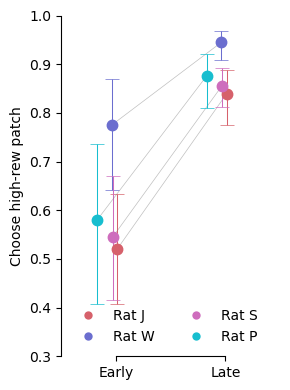

In [41]:
# Make the plot that shows individual rats as dots (with 95% CI) for early learning vs. late learning days.
# Fig 1g, h; patch choices + shift after rewards
save_fig = False
figname = fig_dir+f"j16+wilbur+senor+peanut_{metric_name.lower().replace('-', '').replace(' ', '_')}_early_and_late_days{trial_label}_single_trials.pdf"
if save_fig:
    plot_two_condition_binom(k1, n1, k2, n2, animals=list(late_day.keys()),cond_labels=("Early", "Late"),ylabel=metric_name,save_name=figname)
else:
    plot_two_condition_binom(k1, n1, k2, n2, animals=list(late_day.keys()),cond_labels=("Early", "Late"),ylabel=metric_name)


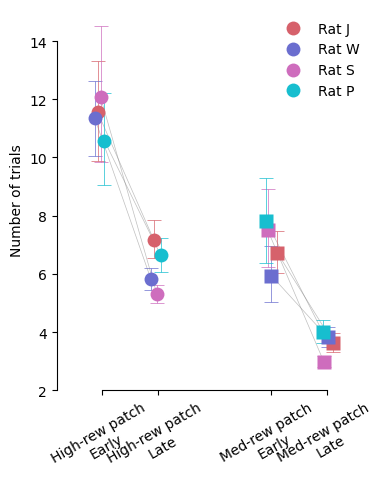

In [42]:
# Fig 1i Bout lengths in early and late learning.
save_fig = False
metric_name ='Bout lengths before switch'
behav_metric1 = dict()
behav_metric2 = dict()
for animal in ['j16','wilbur','senor','peanut']:
    behav_metric1[animal] = {'early': bout_length_best_alltrials[animal][0],'late': np.concatenate([bout_length_best_alltrials[animal][i] for i in late_day[animal]])}
    behav_metric2[animal] = {'early': bout_length_medium_alltrials[animal][0],'late': np.concatenate([bout_length_medium_alltrials[animal][i] for i in late_day[animal]])}

if save_fig:
    figname = fig_dir+f"j16+wilbur+senor+peanut_{metric_name.lower().replace('-', '').replace(' ', '_')}_early_and_late_days{trial_label}_single_trials_withcaps.pdf"
else:
    figname = ""
    
plot_data_pairs(
    behav_metric1,
    behav_metric2,
    point_size=10,
    seed=5,
    pair_labels=("High-rew patch","Med-rew patch"),
    cond_labels=("Early","Late"),
    second_pair_hollow=False,            # <- first pair filled cicles, second hollow circles
    save_name=figname
)

0.06133576233435415
0.0485307214641259
0.03715837969854489
0.06370012160180588
0.03217662467105202
0.07316332478307458
0.010312334055141675
0.038572105358084516


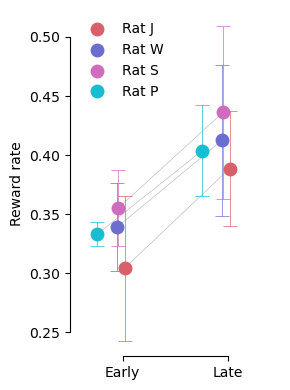

In [22]:
save_fig = False
metric_name = 'Reward rate'
behav_metric = dict()
for animal in ['j16','wilbur','senor','peanut']:
    if metric_name == 'Reward rate':
        behav_metric[animal] = {'early': reward_rate_allrats[animal][0],'late': np.concatenate([reward_rate_allrats[animal][i] for i in late_day[animal]])}
    if metric_name == 'Minimal trials finding high-rew patch':
        behav_metric[animal] = {'early': min_trials_learning[animal][0],'late': np.concatenate([min_trials_learning[animal][i] for i in late_day[animal]])}
    
if save_fig:
    figname = fig_dir+f"j16+wilbur+senor+peanut_{metric_name.lower().replace('-', '').replace(' ', '_')}_min4returns_early_and_late_days_withcaps.pdf"
else:
    figname = ""

plot_two_condition(behav_metric, point_size=10, cond_labels=("Early", "Late"),ylabel=metric_name,save_name=figname)

In [27]:
for animal in ['j16','wilbur','senor','peanut']:
    # stat,p_one_sided = mannwhitneyu(behav_metric[animal][0],np.concatenate([behav_metric[animal][i] for i in late_day[animal]]),alternative='greater')
    stat,p_one_sided = mannwhitneyu(behav_metric[animal]['early'],behav_metric[animal]['late'],alternative='less')
    print(f'{animal}: {stat},{p_one_sided}')

j16: 8.0,0.00976023856194008
wilbur: 11.0,0.011542350876922328
senor: 13.0,0.016382868937048503
peanut: 2.0,0.001332001332001332


## Movement-related variables (e.g., speed in Extended Data Fig. 5)

In [ ]:
subjects = ['j16','wilbur','senor','peanut']
file_names = {'j16':['j1620210714','j1620210716','j1620210717','j1620210718','j1620210719'],\
              'wilbur':['wilbur20210404','wilbur20210406','wilbur20210407','wilbur20210408','wilbur20210409'],\
              'senor':['senor20201109','senor20201111','senor20201114','senor20201116','senor20201121'],\
              'peanut':['peanut20201203','peanut20201205','peanut20201206','peanut20201208','peanut20201209']}

save_results = False
use_selected_sessions = False
exclude_trials_by_duration = False # Cannot use True if we want to find switch to best after best, etc.

aligned_intervals = [[-0.8,0.2],[-2,0.15]]
alignments = ['poke_out_ts','poke_in_ts']

for subject in subjects:
    for idx,alignment in enumerate(alignments):
        for file_name in file_names[subject]:
            if np.isin(file_name,['j1620210714','wilbur20210404','peanut20201203','senor20201109']):
                speed_alldays = []
            speed_per_day = get_movement_data(file=file_name,use_selected_sessions=False,exclude_trials_by_duration=False,alignment=alignment,aligned_interval=aligned_intervals[idx])
            speed_alldays.append(speed_per_day)
    
        # Find the minimal shape and use that to truncate + stack all data of each animal (multi-day)
        min_cols = min(arr.shape[1] for arr in speed_alldays)
        # Truncate each array to min_cols and stack them by row
        speed_array = np.vstack([arr[:, :min_cols] for arr in speed_alldays])
        
        if alignment == 'poke_out_ts':
            speed_pause[subject] = speed_array
        if alignment == 'poke_in_ts':
            speed_run[subject] = speed_array

if save_results:
    np.savez(results_dir+f"j16+wilbur+peanut+senor_speed_across_days_{alignments[0]}{aligned_intervals[0][0]}to{aligned_intervals[0][1]}+{alignments[1]}{aligned_intervals[1][0]}to{aligned_intervals[1][1]}.npz",\
    speed_pause=speed_pause,speed_run=speed_run,allow_pickle=True)


### Plot speed, multi-days per animal

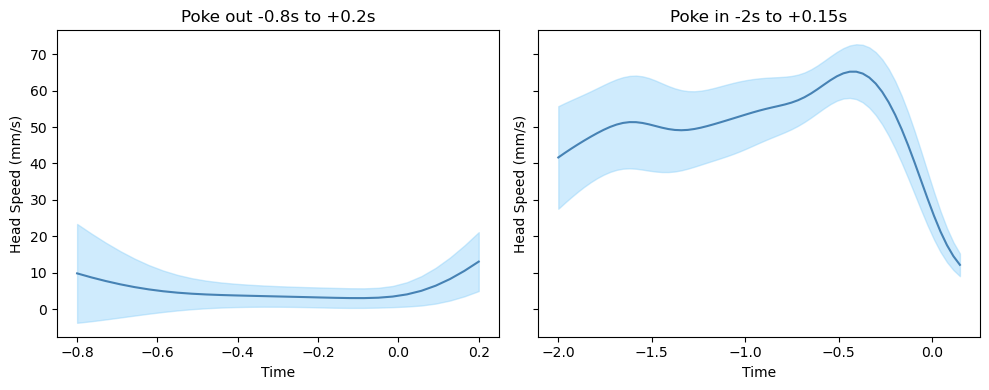

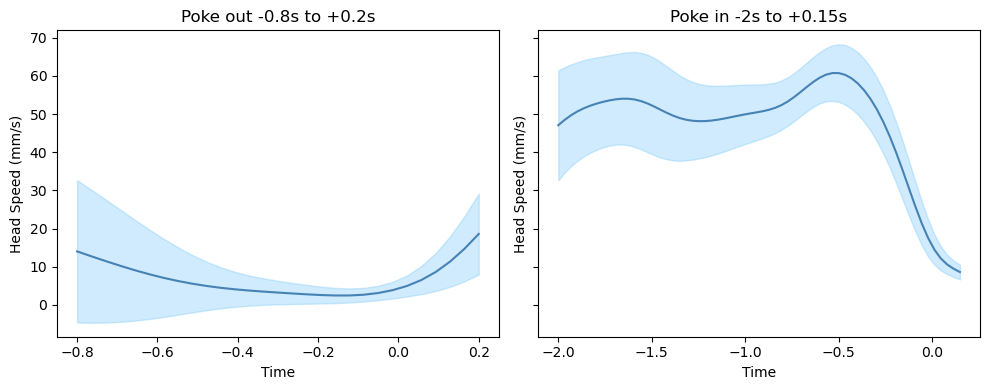

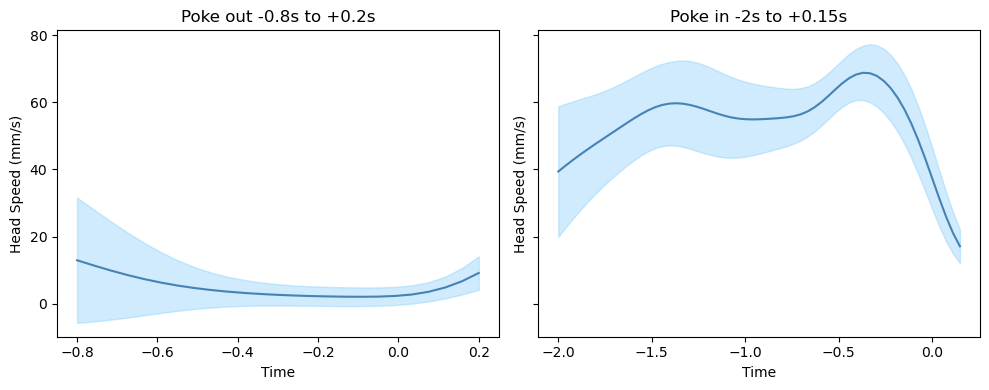

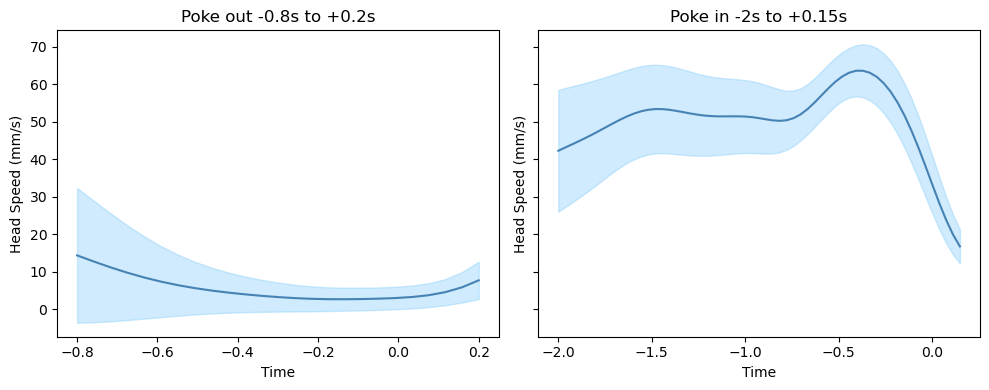

In [15]:
for subject in subjects:
    fig, axes = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(10, 4))
    for j,alignment in enumerate(alignments):
        if alignment == 'poke_out_ts':
            mean_head_speed = speed_pause[subject].mean(axis=0)
            std_head_speed = speed_pause[subject].std(axis=0)
        if alignment == 'poke_in_ts':
            mean_head_speed = speed_run[subject].mean(axis=0)
            std_head_speed = speed_run[subject].std(axis=0)
            
        # time_index = speed_same_length[0].index - myData.TrialTable.iloc[0][alignment]
        time_index = np.linspace(aligned_intervals[j][0], aligned_intervals[j][1], len(mean_head_speed))
        summary_df = pd.DataFrame({
            'time': time_index,
            'mean_head_speed': mean_head_speed,
            'std_head_speed': std_head_speed
        })
        
        # Define upper and lower bounds for the shaded area
        lower = mean_head_speed - std_head_speed
        upper = mean_head_speed + std_head_speed
        
        axes[j].plot(time_index, mean_head_speed, color='steelblue', label='Mean Head Speed')
        axes[j].fill_between(time_index, lower, upper, color='lightskyblue', alpha=0.4, label='±1 Std Dev')
        
        axes[j].set_xlabel("Time")
        axes[j].set_ylabel("Head Speed (mm/s)")
        # axes[j].legend()
        
    axes[0].set_title(f"Poke out {aligned_intervals[0][0]}s to +{aligned_intervals[0][1]}s")
    axes[1].set_title(f"Poke in {aligned_intervals[1][0]}s to +{aligned_intervals[1][1]}s")
    plt.tight_layout()
    
    plt.savefig(fig_dir+f"{subject}_head_speed_runtime2s_pausetime1s.pdf", transparent = True)
